<a href="https://colab.research.google.com/github/noeliacualina/Procesamiento_digital_imagenes/blob/TrabajoPractico_1/TrabajoPractico_N1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**UGR**

#**PROCESAMIENTO DIGITAL DE IMÁGENES**

##**Trabajo Práctico 1**

**Apertura:** jueves, 24 de septiembre de 2026

**Cierre:** lunes, 26 de octubre de 2026

#**Intregrantes:**

Gisela Martinez

Noelia Cualina

José Leonardo Carabajal

Javier Carabajal

#**Objetivo:**

Detectar y clasificar formas geométricas básicas (círculos, cuadrados, triángulos, rectángulos) en imágenes utilizando OpenCV.

#**Descripción:**

Deberán utilizar técnicas de procesamiento de imágenes para identificar formas geométricas.

Pueden presentar el mismo en grupos de hasta 3 alumnos. Deberan  aplicar operaciones de umbralización, detección de bordes y contornos para identificar y clasificar formas.

#**Pasos del Proyecto:**



1.   **Recolección de Datos:**

   *  Recopilar un conjunto de imágenes que contengan formas geométricas básicas.

  *  Pueden crear sus propias imágenes con formas dibujadas


2.   **Preprocesamiento de Datos:**

*  Carga las imágenes y conviértelas a escala de grises.

*  Aplica una operación de umbralización para binarizar la imagen.

*  Utiliza técnicas de suavizado para reducir el ruido.


3.  **Detección de Contornos:**

*  Encuentra los contornos en la imagen umbralizada.

*  Filtra los contornos pequeños que podrían ser ruido.

4.   **Clasificación de Formas:**

*  Clasifica las formas geométricas utilizando la aproximación de contorno.

*  Calcula el perímetro de cada contorno y aplica por ejemplo cv2.approxPolyDP *  para aproximar la forma.

*  Clasifica la forma en función del número de vértices.








#**Entregables:**


*   Código Fuente: Archivo(s) Python con el código del procesamiento de imágenes y clasificación.
*   Informe: Descripción de la metodología, resultados y conclusiones.


## Importación de librerías

In [12]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 1. Recolección de Datos

### 1.1 Carga y visualización de las imágenes.

In [1]:
!git clone -b TrabajoPractico_1 https://github.com/noeliacualina/Procesamiento_digital_imagenes.git

Cloning into 'Procesamiento_digital_imagenes'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 25 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 846.80 KiB | 2.73 MiB/s, done.


In [2]:
!ls Procesamiento_digital_imagenes

imagenes  README.md  TrabajoPractico_N1.ipynb


In [3]:
!ls Procesamiento_digital_imagenes/imagenes

cajas_leche.jpg   latas.jpg	 salvavidas.jpg   ventana_tren.jpg
casa.jpg	  pelota.jpg	 stonehenge.jpg
gato_ventana.jpg  piramides.jpg  televisores.jpg


### Acceso a las imágenes

Las imágenes utilizadas para el procesamiento se encuentran almacenadas en el
repositorio del proyecto. Se clona el repositorio para acceder a ellas desde
el entorno de Google Colab.

## 2. Preprocesamiento de Datos

### 2.1 Carga y conversión a escala de grises

In [13]:
ruta_carpeta = "Procesamiento_digital_imagenes/imagenes"

archivos = sorted([
    archivo for archivo in os.listdir(ruta_carpeta)
    if archivo.lower().endswith((".jpg", ".jpeg", ".png"))
])

print(f"Cantidad de imágenes: {len(archivos)}")
print(archivos)

Cantidad de imágenes: 10
['cajas_leche.jpg', 'casa.jpg', 'gato_ventana.jpg', 'latas.jpg', 'pelota.jpg', 'piramides.jpg', 'salvavidas.jpg', 'stonehenge.jpg', 'televisores.jpg', 'ventana_tren.jpg']


In [14]:
imagenes = {}

for archivo in archivos:
    ruta_imagen = os.path.join(ruta_carpeta, archivo)

    imagen = cv2.imread(ruta_imagen)
    imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

    imagenes[archivo] = {
        "original": imagen,
        "gris": imagen_gris
    }

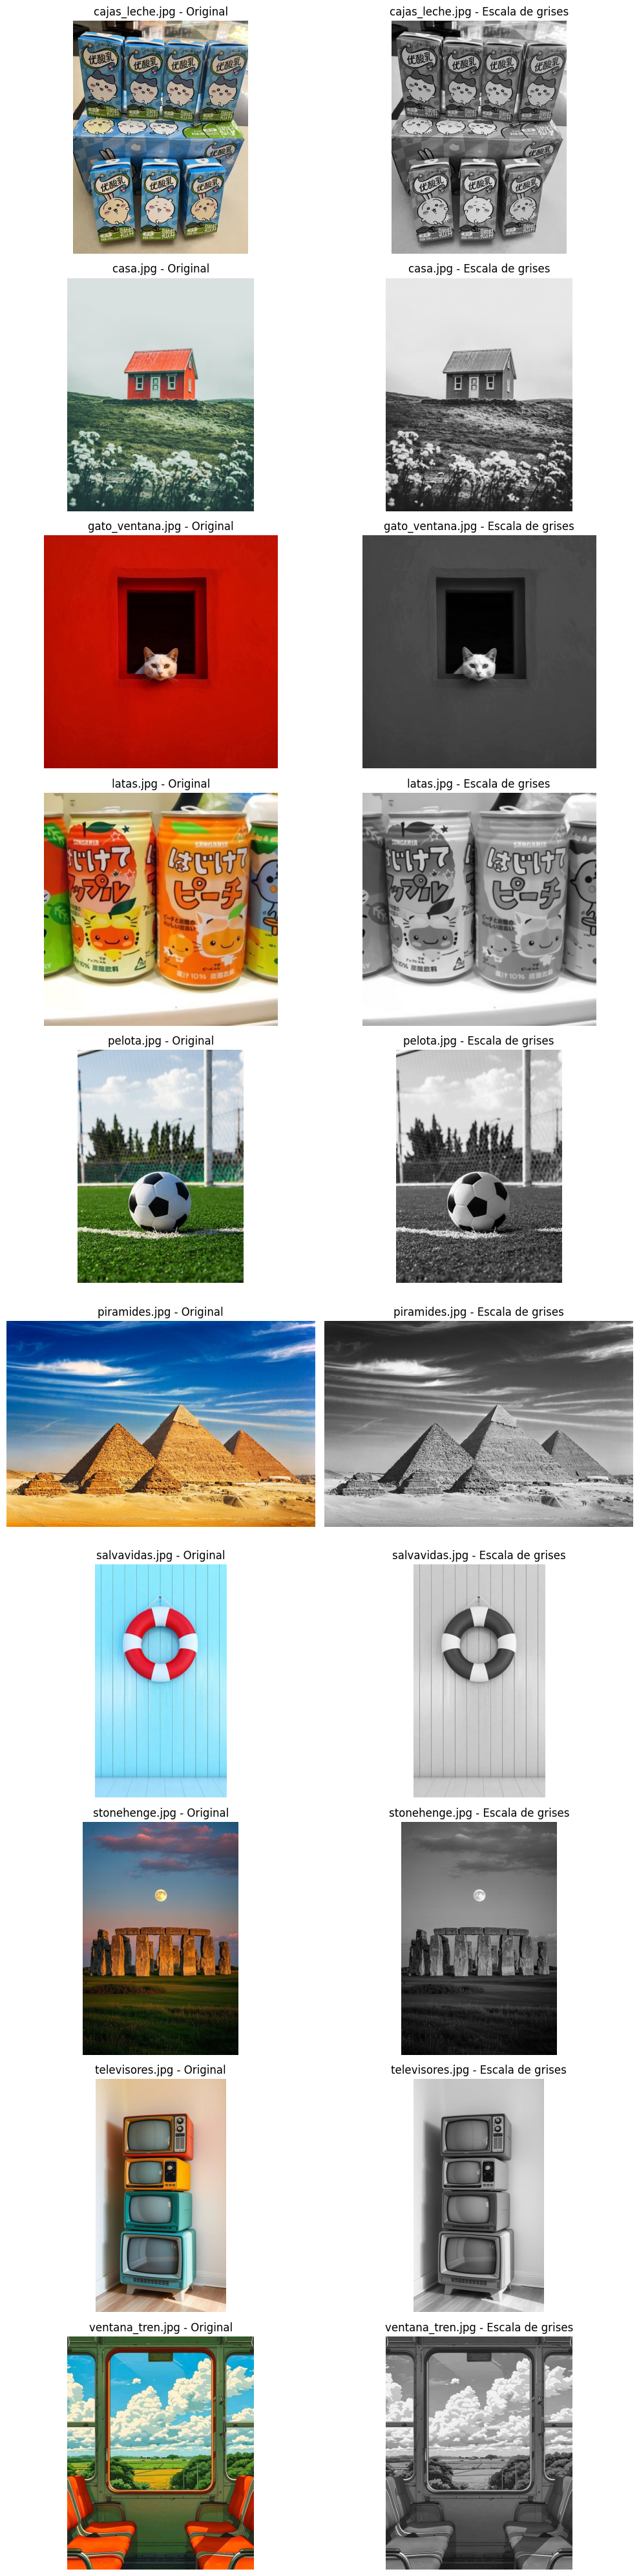

In [15]:
fig, axes = plt.subplots(len(archivos), 2, figsize=(10, 4 * len(archivos)))

for i, archivo in enumerate(archivos):
    original_rgb = cv2.cvtColor(
        imagenes[archivo]["original"],
        cv2.COLOR_BGR2RGB
    )

    axes[i, 0].imshow(original_rgb)
    axes[i, 0].set_title(f"{archivo} - Original")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(imagenes[archivo]["gris"], cmap="gray")
    axes[i, 1].set_title(f"{archivo} - Escala de grises")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

### 2.2 Suavizado para reducción de ruido

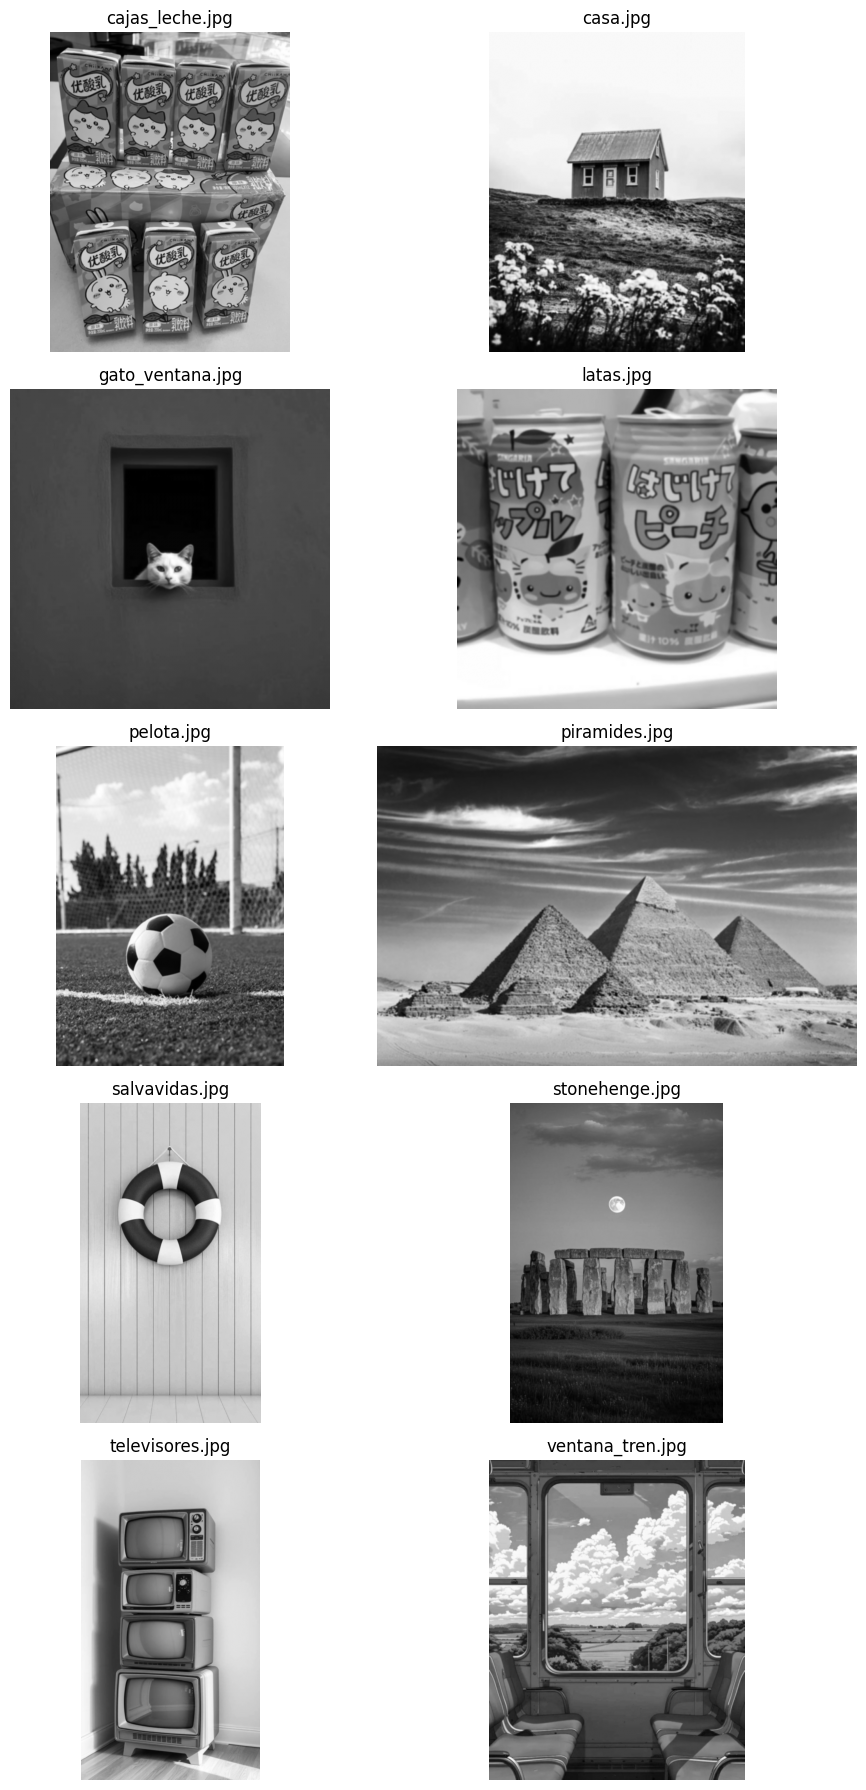

In [16]:
# Reducir pequeñas variaciones, texturas y ruido antes de hacer la binarización:
for archivo in archivos:
    imagenes[archivo]["suavizada"] = cv2.GaussianBlur(
        imagenes[archivo]["gris"],
        (5, 5),
        0
    )


fig, axes = plt.subplots(5, 2, figsize=(10, 18))
axes = axes.flatten()

for i, archivo in enumerate(archivos):
    axes[i].imshow(imagenes[archivo]["suavizada"], cmap="gray")
    axes[i].set_title(archivo)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### 2.3 Umbralización y binarización

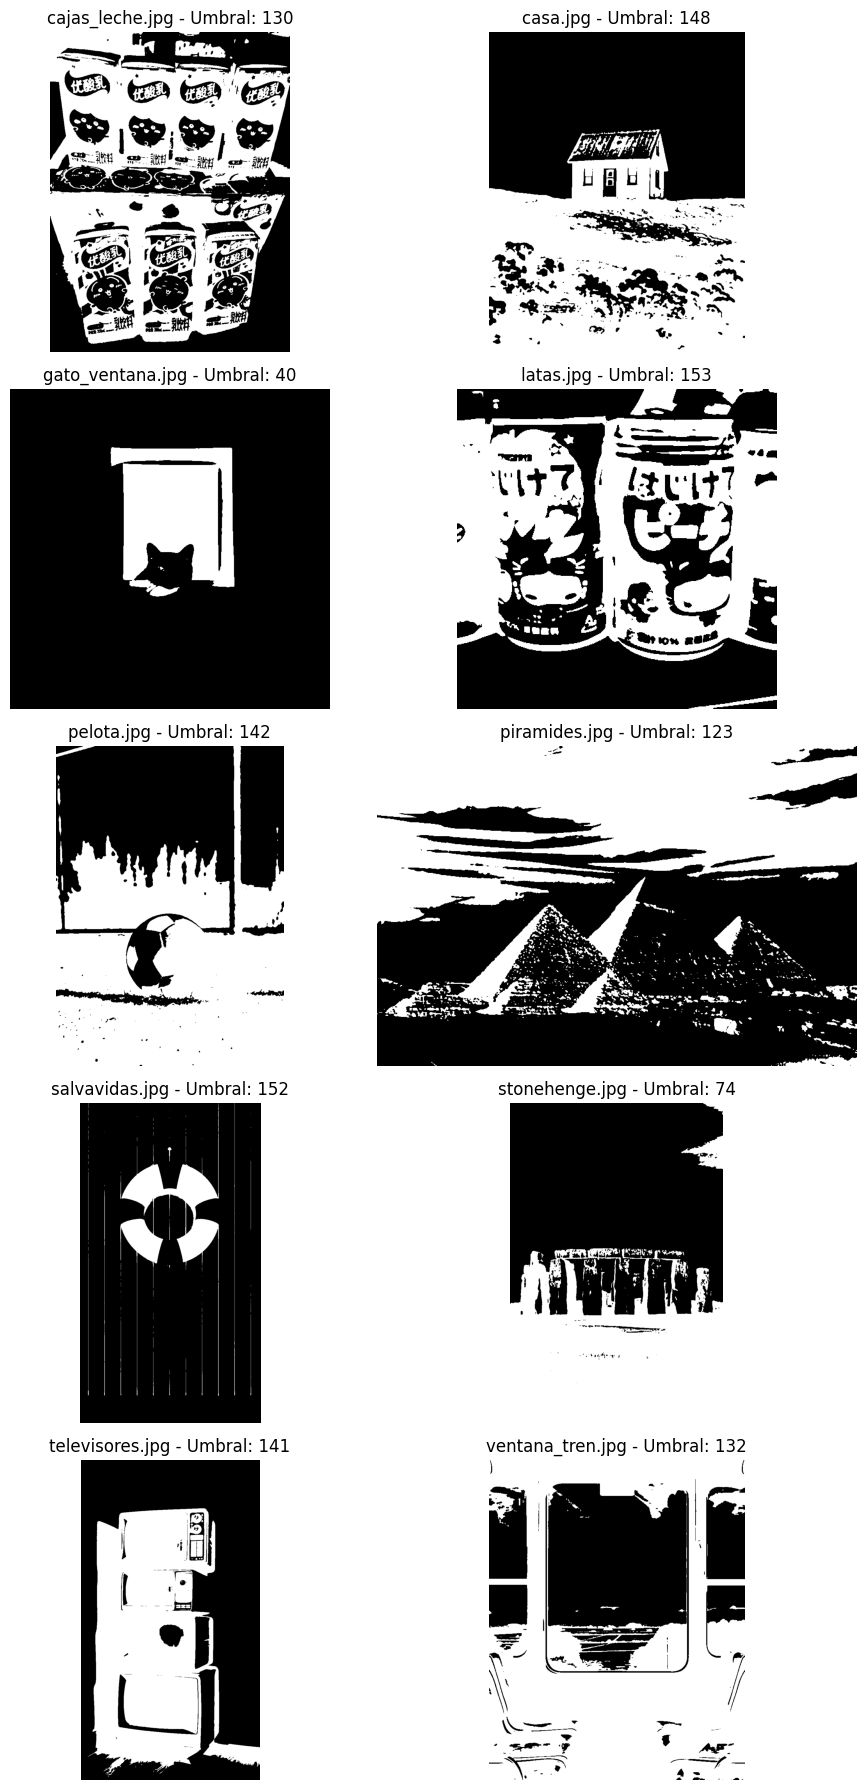

In [18]:
# Determina automáticamente un umbral a partir de la distribución de intensidades de la imagen:

for archivo in archivos:
    umbral, imagen_binaria = cv2.threshold(
        imagenes[archivo]["suavizada"],
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    imagenes[archivo]["umbral"] = umbral
    imagenes[archivo]["binaria"] = imagen_binaria

# Visualizar las 10 binarizaciones

fig, axes = plt.subplots(5, 2, figsize=(10, 18))
axes = axes.flatten()

for i, archivo in enumerate(archivos):
    axes[i].imshow(imagenes[archivo]["binaria"], cmap="gray")
    axes[i].set_title(
        f"{archivo} - Umbral: {imagenes[archivo]['umbral']:.0f}"
    )
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 3. Detección de Contornos

A partir de las imágenes binarizadas se detectan los contornos de los objetos presentes en cada imagen. Posteriormente, se filtran los contornos de menor tamaño para reducir la presencia de ruido.

### 3.1 Detección de contornos

In [19]:
for archivo in archivos:
    contornos, _ = cv2.findContours(
        imagenes[archivo]["binaria"],
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    imagenes[archivo]["contornos"] = contornos

In [20]:
for archivo in archivos:
    print(
        f"{archivo}: "
        f"{len(imagenes[archivo]['contornos'])} contornos detectados"
    )

cajas_leche.jpg: 99 contornos detectados
casa.jpg: 48 contornos detectados
gato_ventana.jpg: 6 contornos detectados
latas.jpg: 44 contornos detectados
pelota.jpg: 38 contornos detectados
piramides.jpg: 641 contornos detectados
salvavidas.jpg: 118 contornos detectados
stonehenge.jpg: 89 contornos detectados
televisores.jpg: 25 contornos detectados
ventana_tren.jpg: 23 contornos detectados


### 3.2 Filtrado de contornos pequeños

Se filtran los contornos de menor tamaño con el objetivo de reducir aquellos que pueden corresponder a ruido, texturas o pequeños detalles de la imagen.

Para que el criterio sea independiente de la resolución de cada imagen, se establece un área mínima equivalente al 0,1 % del área total de la imagen.

In [22]:
# Calcular el área de cada contorno:

porcentaje_area_minima = 0.001

for archivo in archivos:
    alto, ancho = imagenes[archivo]["gris"].shape
    area_imagen = alto * ancho

    area_minima = area_imagen * porcentaje_area_minima

    contornos_filtrados = [
        contorno
        for contorno in imagenes[archivo]["contornos"]
        if cv2.contourArea(contorno) > area_minima
    ]

    imagenes[archivo]["contornos_filtrados"] = contornos_filtrados

In [23]:
# Comparación para ver si realmente se elimina el ruido:

for archivo in archivos:
    total = len(imagenes[archivo]["contornos"])
    filtrados = len(imagenes[archivo]["contornos_filtrados"])

    print(
        f"{archivo}: "
        f"{total} contornos detectados → "
        f"{filtrados} contornos luego del filtrado"
    )

cajas_leche.jpg: 99 contornos detectados → 5 contornos luego del filtrado
casa.jpg: 48 contornos detectados → 3 contornos luego del filtrado
gato_ventana.jpg: 6 contornos detectados → 1 contornos luego del filtrado
latas.jpg: 44 contornos detectados → 6 contornos luego del filtrado
pelota.jpg: 38 contornos detectados → 5 contornos luego del filtrado
piramides.jpg: 641 contornos detectados → 10 contornos luego del filtrado
salvavidas.jpg: 118 contornos detectados → 1 contornos luego del filtrado
stonehenge.jpg: 89 contornos detectados → 3 contornos luego del filtrado
televisores.jpg: 25 contornos detectados → 2 contornos luego del filtrado
ventana_tren.jpg: 23 contornos detectados → 2 contornos luego del filtrado


### 3.3 Visualización de los contornos

In [24]:
# Hacemos una copia de la imagen original para no modificarla:

for archivo in archivos:
    imagen_contornos = imagenes[archivo]["original"].copy()

    cv2.drawContours(
        imagen_contornos,
        imagenes[archivo]["contornos_filtrados"],
        -1,
        (0, 255, 0),
        3
    )

    imagenes[archivo]["resultado_contornos"] = imagen_contornos

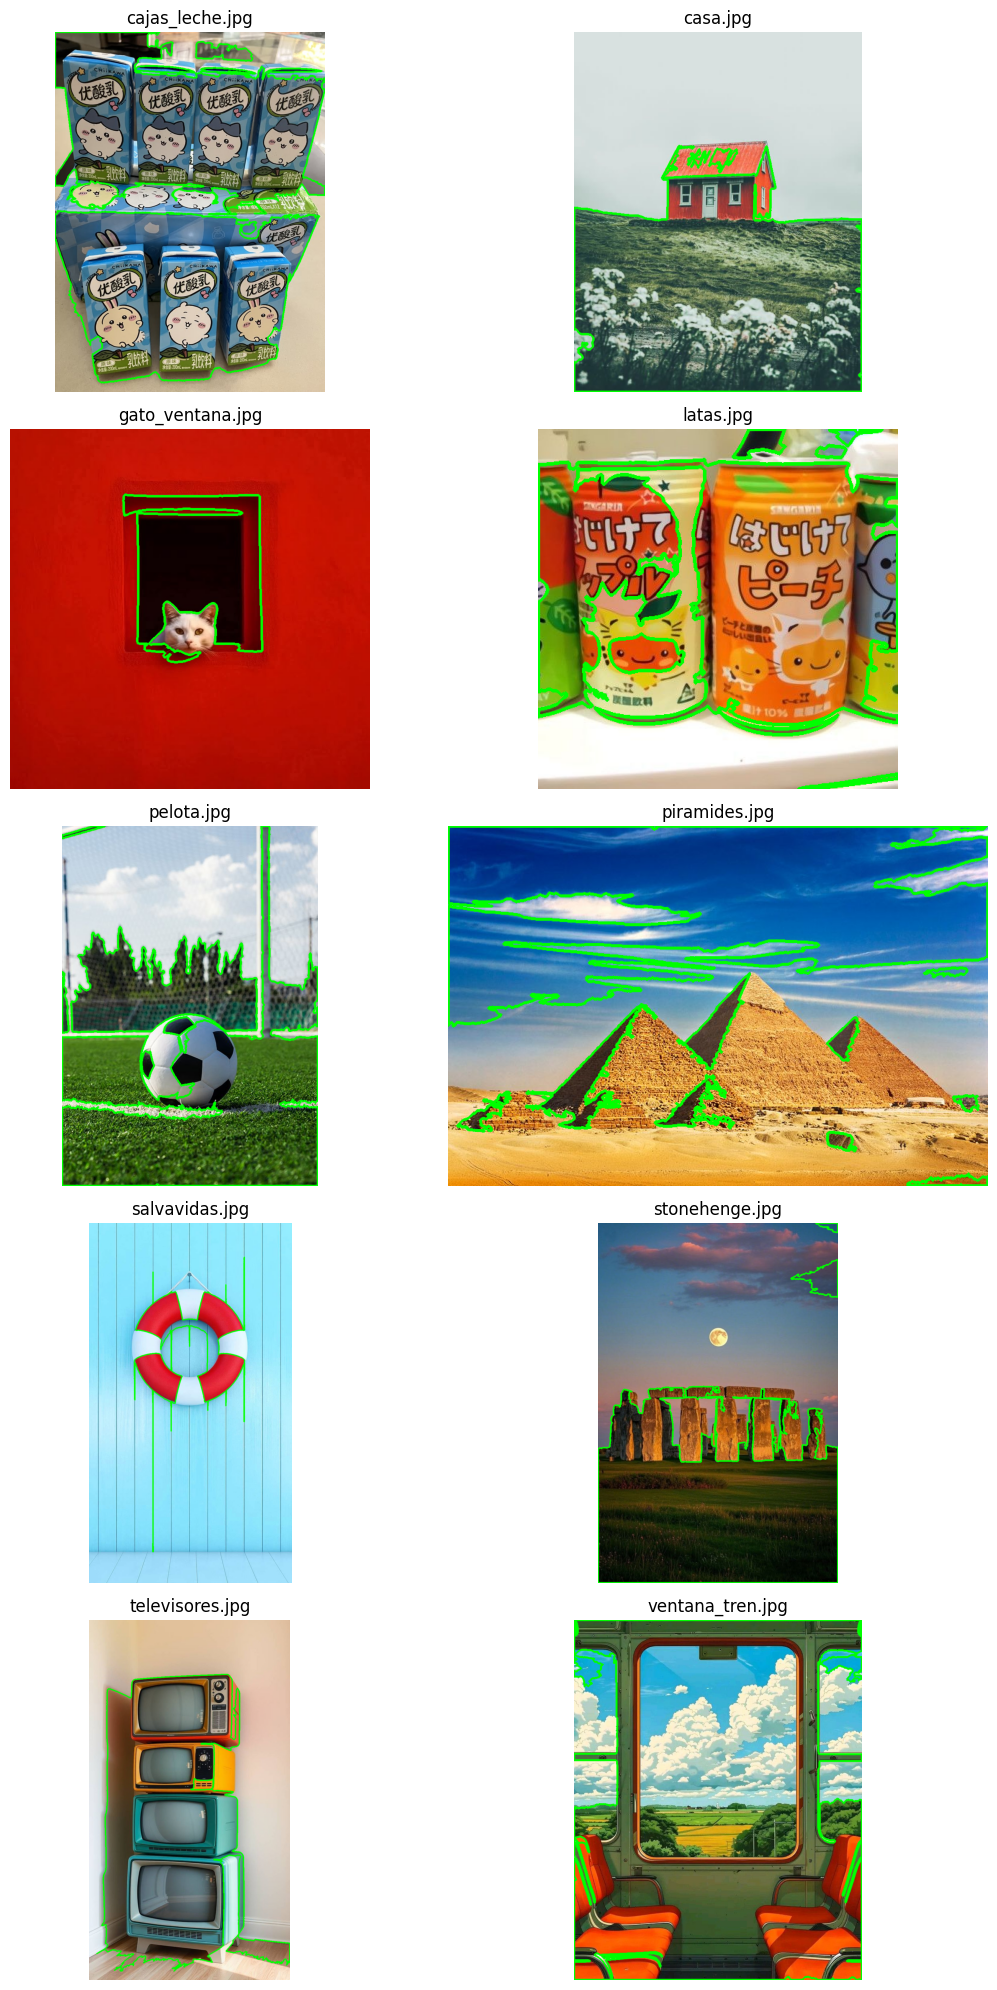

In [25]:
# Visualización de las 10 imágenes:

fig, axes = plt.subplots(5, 2, figsize=(12, 20))
axes = axes.flatten()

for i, archivo in enumerate(archivos):
    resultado_rgb = cv2.cvtColor(
        imagenes[archivo]["resultado_contornos"],
        cv2.COLOR_BGR2RGB
    )

    axes[i].imshow(resultado_rgb)
    axes[i].set_title(archivo)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### Observaciones:

El filtrado por área permite reducir considerablemente la cantidad de contornos
detectados inicialmente, eliminando pequeñas regiones asociadas principalmente
a texturas, detalles y ruido.

Sin embargo, debido a que se utilizan imágenes reales con fondos complejos,
algunos elementos del entorno permanecen como contornos relevantes. Estos
contornos serán analizados posteriormente mediante aproximación poligonal para
determinar si corresponden a alguna de las formas geométricas de interés.